In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1'
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"]="false"
from functools import partial
import time
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy
import glob

import matplotlib as mpl
from matplotlib import rc
rc('font',**{'family':'serif','serif':['Helvetica']})
mpl.rcParams['text.usetex'] = True
mpl.rcParams.update({'font.size': 10})
mpl.rcParams['text.latex.preamble']=r"\usepackage{bm}\usepackage{amsmath}\usepackage{upgreek}"

In [4]:
import jax
import jax.numpy as jnp
# jax.config.update("jax_enable_x64", True)
# jax.config.update("jax_debug_nans", True)
gpus = jax.devices()
print(gpus)

jax.config.update("jax_default_device", gpus[0])

import diffrax
import equinox as eqx
import optax

from haiku import PRNGSequence

import exciting_environments as excenvs

from dmpe.data_management import DataPaths
from dmpe.evaluation.plotting_utils import plot_sequence
from dmpe.evaluation.experiment_utils import get_experiment_ids, load_experiment_results
from dmpe.models.models import NeuralEulerODECartpole
from dmpe.models.model_utils import simulate_ahead_with_env

[cuda(id=0)]


In [5]:
from dmpe.utils.env_utils.fluid_tank_utils import setup_env as setup_fluid_tank_env
from dmpe.utils.env_utils.pendulum_utils import setup_env as setup_pendulum_env
from dmpe.utils.env_utils.cart_pole_utils import setup_env as setup_cart_pole_env

In [6]:
from dmpe.utils.density_estimation import build_grid
from dmpe.models.model_utils import simulate_ahead_with_env

In [7]:
from dmpe.utils.sets.reachable_set import approximate_reachable_set
from dmpe.utils.sets.control_invariant_set import approximate_control_invariant_set

from dmpe.utils.sets.reachable_set import save_results as save_results_rs
from dmpe.utils.sets.control_invariant_set import save_results as save_results_ci
from dmpe.utils.sets.shared import load_results, DiscretizedSet, SlicedSet, load_discretized_set, save_discretized_set

In [8]:
import matplotlib as mpl
from matplotlib import rc
rc('font',**{'family':'serif','serif':['Helvetica']})
mpl.rcParams['text.usetex'] = True
mpl.rcParams.update({'font.size': 10 * 2.54})
mpl.rcParams['text.latex.preamble']=r"\usepackage{bm}\usepackage{amsmath}\usepackage{upgreek}"

full_column_width = 18.2
half_column_width = 8.89

In [9]:
from enum import Enum
class Systems(Enum):
    FLUID_TANK = 1
    PENDULUM = 2
    CART_POLE = 3

In [108]:
env, penalty_function, featurize, _ = setup_cart_pole_env()
R_s = load_discretized_set(DataPaths().reach_ci_experiments / "cart_pole_Rs_a10d3279-68f6-4d.json")
C = load_discretized_set(DataPaths().reach_ci_experiments / "cart_pole_C_069e72af-6e6f-46.json")

In [152]:
def visualize_S_xu(
    S_xu, reduction_method=jnp.mean, labels: None | list[str] = None, use_contourf: bool = True, scaling=1.0,
):

    dim = S_xu.grid.shape[-1]
    if dim > 2:
        fig, axs = plt.subplots(nrows=dim, ncols=dim, figsize=(half_column_width*scaling, half_column_width*scaling), sharex=True, sharey=True)
        feature_indices = jnp.arange(0, dim, 1).tolist()
    
        if labels is None:
            labels = jnp.arange(0, dim, 1).tolist()
    
        for i in range(dim):
            for j in range(dim):
    
                axs[j, i].grid(True)
    
                reduction_indices = [f_idx for f_idx in feature_indices if not (f_idx == i or f_idx == j)]
                if len(reduction_indices) == dim - 1:
                    continue
    
                reduced_safe = reduction_method(S_xu.mask_unflattened, axis=tuple(reduction_indices))
    
                if i > j:
                    reduced_safe = jnp.transpose(reduced_safe)
    
                if use_contourf:
                    contourset = axs[j, i].contourf(
                        S_xu.grid_unflattened[..., *[0 for _ in range(dim - 2)], 0],
                        S_xu.grid_unflattened[..., *[0 for _ in range(dim - 2)], 1],
                        reduced_safe,
                        vmin=0.0,
                        vmax=1.0,
                    )
                else:
                    axs[j, i].imshow(reduced_safe.T, origin="lower", extent=[-1, 1, -1, 1])
                axs[j, 0].set_ylabel(labels[j])
       
            axs[-1, i].set_xlabel(labels[i])
        #fig.tight_layout()
        return fig, axs
    if dim == 2:
        fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(half_column_width*scaling, half_column_width*scaling))
        ax.grid(True)
        contourset = ax.contourf(
            S_xu.grid_unflattened[..., *[0 for _ in range(dim - 2)], 0],
            S_xu.grid_unflattened[..., *[0 for _ in range(dim - 2)], 1],
            S_xu.mask_unflattened,
            vmin=0.0,
            vmax=1.0,
        )
        ax.set_xlabel(labels[0])
        ax.set_ylabel(labels[1])
    
        return fig, ax
    

(<Figure size 889x889 with 16 Axes>,
 array([[<Axes: ylabel='0'>, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='1'>, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='2'>, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: xlabel='0', ylabel='3'>, <Axes: xlabel='1'>,
         <Axes: xlabel='2'>, <Axes: xlabel='3'>]], dtype=object))

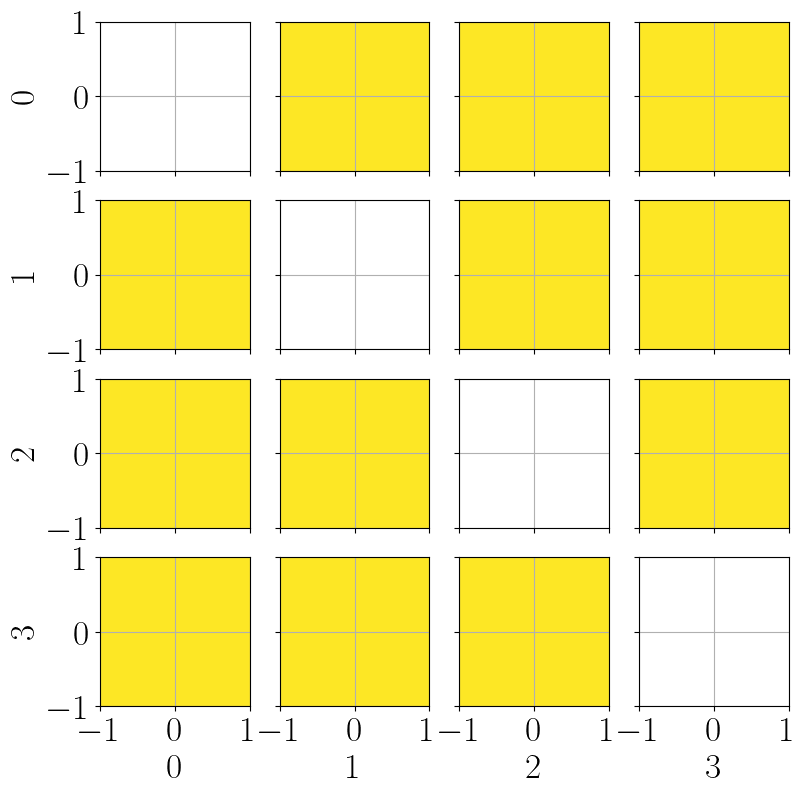

In [153]:
naive_set = DiscretizedSet(grid=R_s.grid, mask=jnp.ones(R_s.mask.shape), unflattened_shape=R_s.unflattened_shape)
visualize_S_xu(naive_set)


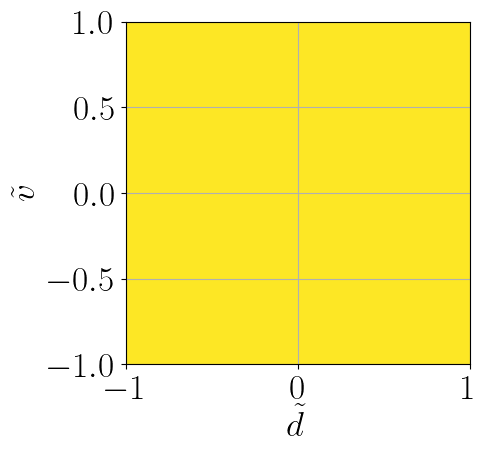

In [157]:
naive_set = DiscretizedSet(grid=build_grid(2, -1, 1, 25), mask=jnp.ones(25*25), unflattened_shape=(25,25))
fig, _ = visualize_S_xu(naive_set, reduction_method=jnp.mean, labels=[r"$\tilde{d}$", r"$\tilde{v}$"], use_contourf=True, scaling=0.5)
plt.savefig(f"cartpole_2d_naive_target_space.pdf", bbox_inches='tight');

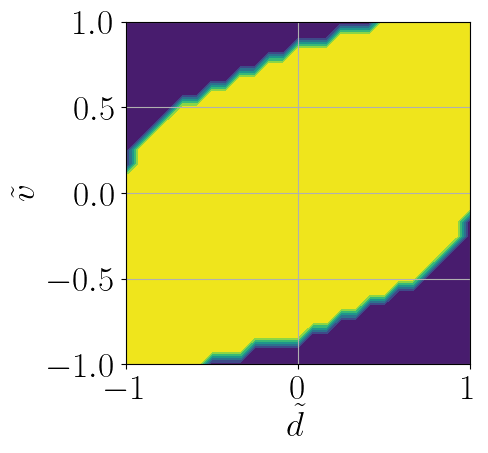

In [159]:
R_s2d = DiscretizedSet(grid=build_grid(2, -1, 1, 25), mask=jnp.any(R_s.mask_unflattened, axis=(2,3)).astype(float), unflattened_shape=(25,25))
fig, _ = visualize_S_xu(R_s2d, reduction_method=jnp.mean, labels=[r"$\tilde{d}$", r"$\tilde{v}$"], use_contourf=True, scaling=0.5)
plt.savefig(f"cartpole_2d_Rs.pdf", bbox_inches='tight');

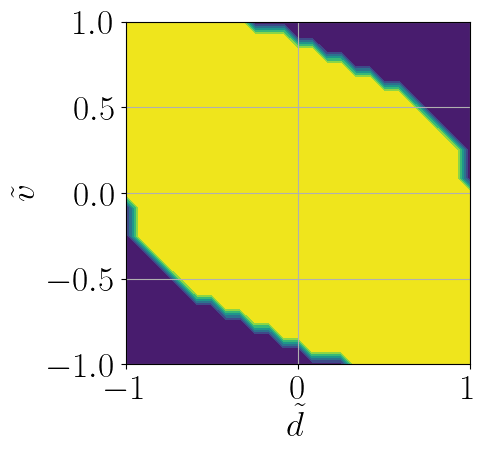

In [161]:
C_2d = DiscretizedSet(grid=build_grid(2, -1, 1, 25), mask=jnp.any(C.mask_unflattened, axis=(2,3)).astype(float), unflattened_shape=(25,25))
fig, _ = visualize_S_xu(C_2d, reduction_method=jnp.mean, labels=[r"$\tilde{d}$", r"$\tilde{v}$"], use_contourf=True, scaling=0.5)
plt.savefig(f"cartpole_2d_C.pdf", bbox_inches='tight');

---

In [88]:
env, penalty_function, featurize, _ = setup_pendulum_env()
# env_params = dict(
#     batch_size=1,
#     tau=5,
#     max_height=3,
#     max_inflow=0.1,
#     base_area=jnp.pi,
#     orifice_area=jnp.pi * 0.1**2,
#     c_d=0.6,
#     g=9.81,
#     env_solver=diffrax.Tsit5(),
# )
# env = excenvs.make(
#     "FluidTank-v0",
#     physical_normalizations=dict(height=excenvs.utils.MinMaxNormalization(min=0, max=env_params["max_height"])),
#     action_normalizations=dict(inflow=excenvs.utils.MinMaxNormalization(min=0, max=env_params["max_inflow"])),
#     static_params=dict(
#         base_area=env_params["base_area"],
#         orifice_area=env_params["orifice_area"],
#         c_d=env_params["c_d"],
#         g=env_params["g"],
#     ),
#     tau=env_params["tau"],
#     solver=env_params["env_solver"],
# )

In [89]:
from dmpe.utils.sets.control_invariant_set import approximate_control_invariant_set_through_chunks
from dmpe.utils.sets.reachable_set import approximate_reachable_set_through_chunks

In [91]:
key = jax.random.PRNGKey(14)

obs_dim = env.reset(env.env_properties)[0].shape[-1]
sequence_length = 200
n_starts = 10
n_opt_steps = 1000
points_per_dim = 25
chunk_size = 20_000

xs = [
    jnp.linspace(-1.0, 1.0, points_per_dim),
    jnp.linspace(-1.0, 1.0, points_per_dim),
]
z_g = jnp.meshgrid(*xs, indexing="ij")
z_g = jnp.stack([_x for _x in z_g], axis=-1)
unflattened_shape = z_g.shape[:-1]
init_observations = z_g.reshape(-1, obs_dim)

C = approximate_control_invariant_set_through_chunks(
    env,
    chunk_size,
    init_observations,
    penalty_function,
    key=key,
    sequence_length=sequence_length,
    n_starts=n_starts,
    n_opt_steps=n_opt_steps,
    unflattened_shape=unflattened_shape,
)

Running for 1,000 iterations:   0%|          | 0/1000 [00:00<?, ?it/s]

In [93]:
key = jax.random.PRNGKey(14)

obs_dim = env.reset(env.env_properties)[0].shape[-1]
sequence_length = 200
n_starts = 100
n_opt_steps = 1_000
tolerance = 1e-4
points_per_dim = 25
chunk_size = 20_000

xs = [
    jnp.linspace(-1.0, 1.0, points_per_dim),
    jnp.linspace(-1.0, 1.0, points_per_dim),
]
z_g = jnp.meshgrid(*xs, indexing="ij")
z_g = jnp.stack([_x for _x in z_g], axis=-1)
unflattened_shape = z_g.shape[:-1]
target_observations_rs = z_g.reshape(-1, obs_dim)

R_s = approximate_reachable_set_through_chunks(
    env,
    chunk_size,
    target_observations_rs,
    penalty_function,
    featurize,
    key=key,
    sequence_length=sequence_length,
    n_starts=n_starts,
    n_opt_steps=n_opt_steps,
    tolerance=tolerance,
    unflattened_shape=unflattened_shape,
)

Running for 1,000 iterations:   0%|          | 0/1000 [00:00<?, ?it/s]

In [102]:
observations = C.grid
actions = jnp.linspace(-1, 1, C.unflattened_shape[0])[..., None]

def fuse_obs_act(observations, action):
    return jnp.concatenate([observations, action.repeat(observations.shape[0])[:, None]], axis=-1)

@eqx.filter_jit
def step_from_init_obs(init_obs, action, env):
    init_state = env.generate_state_from_observation(init_obs, env.env_properties)
    next_obs, _ = env.step(init_state, action, env.env_properties)
    return next_obs

In [103]:
obs_dim = env.reset(env.env_properties)[0].shape[-1]

fused = eqx.filter_vmap(fuse_obs_act, in_axes=(None, 0), out_axes=(1))(observations, actions).reshape(-1, obs_dim+env.action_dim)

# simulate one step ahead
next_observations = eqx.filter_vmap(eqx.filter_vmap(step_from_init_obs, in_axes=(None, 0, None)), in_axes=(0, None, None))(observations, actions, env)

# next_observations.reshape([points_per_dim] * dim + [-1]).shape
next_observations = next_observations.reshape([-1, obs_dim])

In [104]:
out = []
chunk_size = 20_000
n_observations = next_observations.shape[0]

for i in tqdm(jnp.arange(0, n_observations, chunk_size)):
    next_obs = next_observations[i : min(i + chunk_size, n_observations)] 
    out.append(eqx.filter_vmap(C.check_in_set)(next_obs))
out = jnp.concatenate(out)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 14.42it/s]


In [105]:
C_xu = DiscretizedSet(
    grid=fused,
    mask=out,
    unflattened_shape=tuple([*C.unflattened_shape, actions.shape[0]]),
)

In [106]:
C_xu

DiscretizedSet(
  grid=f32[15625,3],
  mask=bool[15625],
  unflattened_shape=(25, 25, 25)
)

(<Figure size 900x900 with 9 Axes>,
 array([[<Axes: ylabel='theta'>, <Axes: >, <Axes: >],
        [<Axes: ylabel='omega'>, <Axes: >, <Axes: >],
        [<Axes: xlabel='theta', ylabel='torque'>, <Axes: xlabel='omega'>,
         <Axes: xlabel='torque'>]], dtype=object))

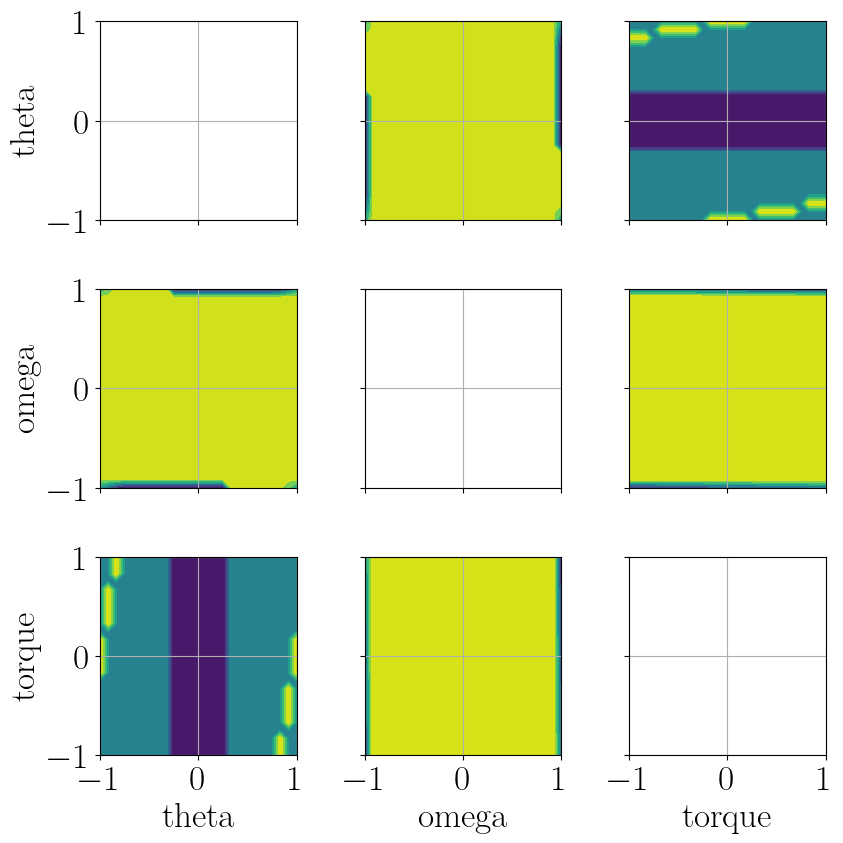

In [107]:
C_xu.visualize(jnp.sum, labels=[*env.obs_description, *env.action_description])

In [ ]:
R_s_xu = DiscretizedSet(
    grid=C_xu.grid,
    mask=R_s.mask[..., None].repeat(C_xu.unflattened_shape[-1], axis=-1).flatten(),
    unflattened_shape=C_xu.unflattened_shape,
)

In [ ]:
S_xu = C_xu & R_s_xu

In [ ]:
S_xu.visualize()

(<Figure size 900x900 with 1 Axes>, <Axes: >)

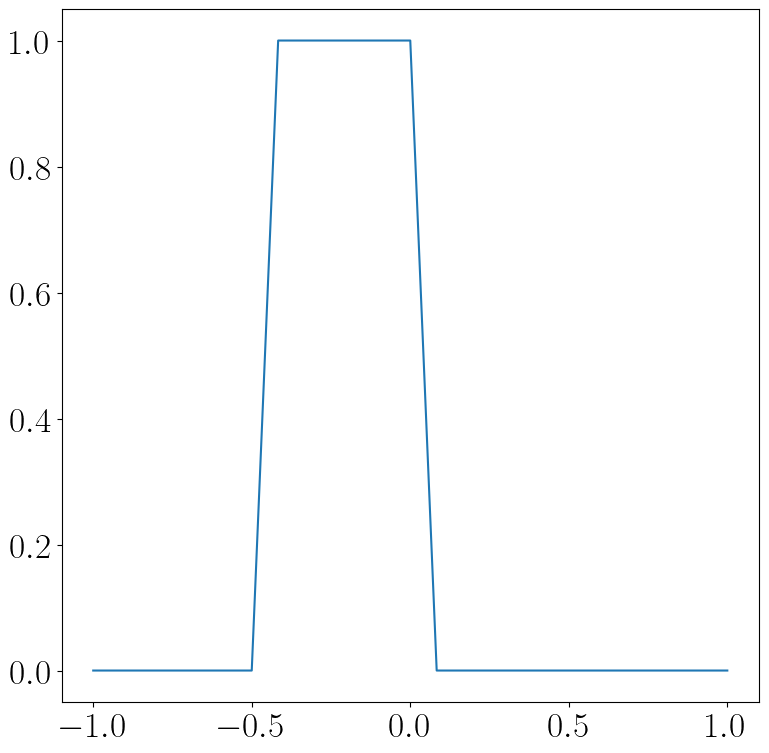

In [73]:
R_s.visualize()

In [70]:
fig, axs = visualize_S_xu(S_xu, use_contourf=True, labels=labels, scaling=scaling)

NameError: name 'labels' is not defined